# Experiments on Arbitrary Routes
This notebook contains experiments that build intuition about the effects of various holding policies and stop placements in a route.

In [1]:
from copy import deepcopy
from dataclasses import dataclass
from os import path

from plotly import express, graph_objects, subplots

from analysis.policies import *
from analysis.routes import *
from analysis.prob_analysis import *
from analysis.wc_analysis import *

## Plotting Helpers

In [2]:
@dataclass
class RouteConfig(object):
    """Configuration information that defines a route variant under test.
    
    :param name: Name used for identification.
    :param route: List of stops.
    :param start_times: List of times when vehicles start serving the route.
    """ 
    name: str
    route: list[Stop]
    start_times: list[float]

In [3]:
@dataclass
class HeadwayResults(object):
    """Headway experiment results.
    
    :param upper_bound: List of maximum possible headway at each stop.
    :param lower_bound: List of minimum possible headway at each stop.
    :param observed: List of headway times observed during simulation at each stop.
    """ 
    upper_bound: list[float]
    lower_bound: list[float]
    observed: list[list[float]]

In [4]:
@dataclass
class RouteResults(object):
    """Results from an experiment on one route variant.
    
    :param name: Name used for identification.
    :param route: The route under consideration.
    :param headway: Simulated and analytical headway results for the route.
    :param travel_time: Measured travel times between all pairs of stops.
    """ 
    name: str
    route: list[Stop]
    headway: HeadwayResults
    travel_time: list[list[list[float]]]

In [5]:
def plot_headway(exp_id: str, results: list[RouteResults]) -> None:
    """Plot simulated and analytical headway bounds.

    :param exp_id: Experiment name used used when saving the figure.
    :param results: List of results for each route under consideration.
    """
    fig = graph_objects.Figure()
    whitespace = 0.2
    width = (1 - whitespace) / len(results)

    for i, result in enumerate(results):
        offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width

        for stop_idx in range(len(result.route)):
            fig.add_trace(graph_objects.Bar(
                base=[result.headway.lower_bound[stop_idx]],
                legend='legend1',
                marker={'color': express.colors.qualitative.T10[i]},
                marker_pattern_shape='x',
                name='$' + result.name + r'\textrm{ (Bounds)}' + '$',
                opacity=0.5,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset],
                y=[result.headway.upper_bound[stop_idx]],
            ))
            fig.add_trace(graph_objects.Box(
                legend='legend2',
                marker={'color': express.colors.qualitative.T10[i]},
                name='$' + result.name + r'\textrm{ (Sim.)}' + '$',
                opacity=1.0,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset] * len(result.headway.observed[stop_idx]),
                y=result.headway.observed[stop_idx],
            ))

    fig.update_layout(
        # General style
        font_family='Times New Roman, serif',
        plot_bgcolor='white',

        # Dimensions
        height=360,
        width=750,

        # Axes
        xaxis=dict(
            side='top',
            tickmode='array',
            tickvals=[j for j in range(max([len(r.route) for r in results]))],
            title='Stop #',
            title_standoff=0.0,
        ),
        yaxis=dict(
            gridcolor='lightgrey',
            showgrid=True,
            title='Headway Time (min.)',
            title_standoff=0.0,
            zeroline=True,
            zerolinecolor='lightgrey',
        ),

        # Legends
        legend1=dict(
            orientation='v',
            x=0.25,
            xanchor='center',
            y=-0.4,
            yanchor='bottom',
        ),
        legend2=dict(
            orientation='v',
            x=0.75,
            xanchor='center',
            y=-0.4,
            yanchor='bottom',
        ),
    )

    fig.show()
    fig.write_image(path.join('figures', f'{exp_id}.pdf'))

In [6]:
def plot_travel(results: list[RouteResults]):
    """Plot in-vehice travel time for the simulated route.

    :param results: List of results for each route under consideration.
    """
    fig = subplots.make_subplots(
        cols=len(results),
        column_titles=[r.name for r in results],
        rows=1,
        x_title='To Stop #',
        y_title='Worst Case<br>Travel Time From Stop #',
    )

    # Normalize Color Scales
    absolute_max = 0
    absolute_min = float('inf')
    for result in results:
        for i in results.travel_time:
            for j in i:
                absolute_max = max(absolute_max, max(j))
                absolute_min = min(absolute_min, min(j))
    
    # Plot The Thing
    for idx, result in enumerate(results):
        fig.add_trace(
            go.Heatmap(
                showscale=False,
                text=z,
                texttemplate='%{text:.0f}',
                z=[[max(k) for k in j] for j in result.travel_time],
                zmax=absolute_max,
                zmin=absolute_min,
            ),
            col=idx + 1,
            row=1,
        )

    fig.show()

In [7]:
def run_experiment(exp_id: str, routes: list[RouteConfig], t_max: float) -> None:
    """Run an experiment.

    :param exp_id: Experiment name.
    :param routes: The routes (including start times) to compare.
    :param t_max: The cutoff time for simulation and analytical analysis.
    """
    results = []
    for route in routes:
        print(f'Working on {route.name}...')
        headway_ub, headway_lb = headway_bounds(route_factory(route.route), route.start_times, t_max)
        pr_results = simulate(route_factory(route.route), route.start_times, t_max)
        results.append(RouteResults(
            name=route.name,
            route=route.route,
            headway=HeadwayResults(upper_bound=headway_ub, lower_bound=headway_lb, observed=pr_results['headway']),
            travel_time=pr_results['travel'],
        ))

    plot_headway(exp_id, results)
    plot_travel(results)


## Exp 1: Holding Policy at All Stops
Consider the case where every stop along a route has an identical holding policy applied.

Working on \pi\texttt{NIL}...
Working on \pi\texttt{SCH}...
Working on \pi\texttt{DYN}...


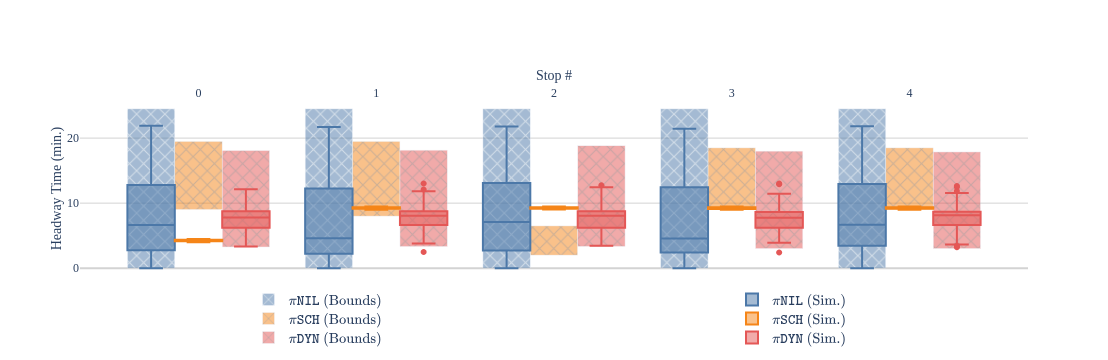

FileNotFoundError: [Errno 2] No such file or directory: 'figures/holdstop12345.pdf'

In [8]:
T_MAX = 60 * 24 * 7
N_STOPS = 5
BASE_ROUTE = [
    StopConfig(
        tau=(4, 4.5),
        delta=(0, 0.5),
        policy=BolehPolicy,
        policy_args={},
    ) for _ in range(N_STOPS)
]
START_TIMES = [0, 10, 20]

# Scheduled terminal departure
SCHED_ROUTE = deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    SCHED_ROUTE[i].policy = InfiniteSchedulePolicy
    SCHED_ROUTE[i].policy_args = {'time_delta': 10, 'offset':  5 * i}

# Headway driven holding
HEADWAY_ROUTE = deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    HEADWAY_ROUTE[i].policy = HeadwayDrivenPolicy
    HEADWAY_ROUTE[i].policy_args = {'activation_ratio': 0.75, 'max_holding': float('inf')}

routes = [
    RouteConfig(name=r'\pi\texttt{NIL}', route=BASE_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{SCH}', route=SCHED_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}', route=HEADWAY_ROUTE, start_times=START_TIMES),
]

run_experiment(exp_id='holdstop12345', routes=routes, t_max=T_MAX)

In [ ]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0.0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': float('inf')}

routes = {
    r'\pi\texttt{NIL}': BASE_ROUTE,
    r'\pi\texttt{SCH}': SCHED_ROUTE,
    r'\pi\texttt{DYN}': RATIO_ROUTE,
}

run_experiment(
    exp_id='exp-base',
    routes=routes,
    start_times=[0, 10, 20],
    t_max=60 * 24 * 7,
)

## Fig. 1: All Points Controlled
We now consider the effects of different policies when applied to every stop along a route.

Setting:
* 10 stops, average completion time uncontrolled: 60 minutes
* 6 vehicles

TODO:
* Outlier headway time on Headway Policy when buses released simultaneously

## Fig. 2: Terminal and Midpoint Holding Only
We now consider the effect of applying a policy only at the terminal and at route midpoint.  The setting is the same as the previous figure.

TODO:
* Travel time calculation is incorrect for headway 

Working on \pi\texttt{SCH}\;@s^{(0)}, s^{(2)}...
Working on \pi\texttt{DYN}\;@s^{(0)}, s^{(2)}...
Working on \pi\texttt{DYN}\;@s^{(0)},\;\pi\texttt{SCH}\;@s^{(2)}...


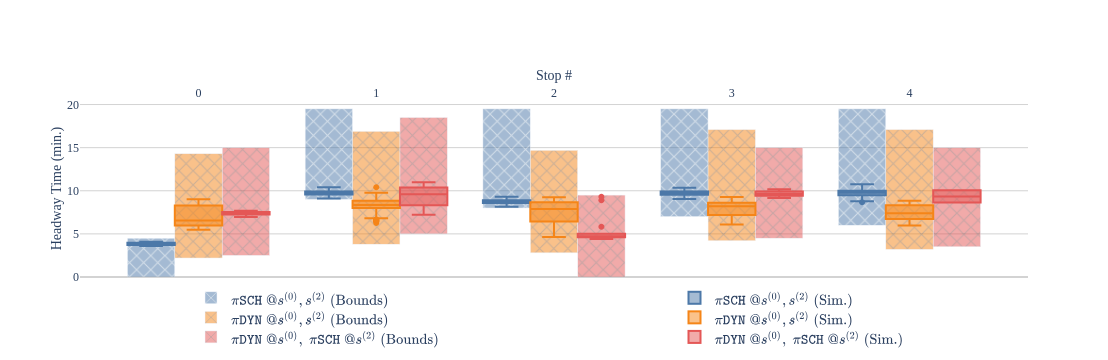

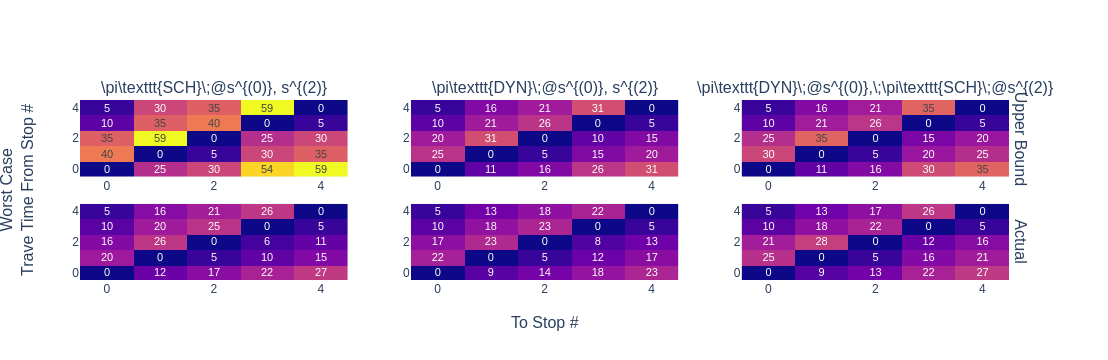

In [44]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}
SCHED_ROUTE[2]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[2]['policy_args'] = {'time_delta': 10, 'offset': 5 * 2}


# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': float('inf')}
RATIO_ROUTE[2]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[2]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': float('inf')}


# Headway Driven Route tries to maintain constant headway regardless of delay
SR_ROUTE = copy.deepcopy(BASE_ROUTE)
SR_ROUTE[0]['policy'] = LeakyBucketPolicy
SR_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}
SR_ROUTE[2]['policy'] = RatioDrivenPolicy
SR_ROUTE[2]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': float('inf')}

# Headway Driven Route tries to maintain constant headway regardless of delay
RS_ROUTE = copy.deepcopy(BASE_ROUTE)
RS_ROUTE[0]['policy'] = RatioDrivenPolicy
RS_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': float('inf')}
RS_ROUTE[2]['policy'] = LeakyBucketPolicy
RS_ROUTE[2]['policy_args'] = {'time_delta': 10, 'offset': 2.5 * 4}

routes = {
    #'Uncontrolled': BASE_ROUTE,
    r'\pi\texttt{SCH}\;@s^{(0)}, s^{(2)}': SCHED_ROUTE,
    r'\pi\texttt{DYN}\;@s^{(0)}, s^{(2)}': RATIO_ROUTE,
    r'\pi\texttt{DYN}\;@s^{(0)},\;\pi\texttt{SCH}\;@s^{(2)}': RS_ROUTE,
    #r'$\pi\texttt{DYN}\;@s^{(0)},\;\pi\texttt{SCH}\;@s^{(4)}$': RS_ROUTE,
}

run_experiment(
    exp_id='fig2-midpoint-holding',
    routes=routes,
    start_times=[0, 10, 20],

    t_max=60 * 24 * 7,
)

## Fig. 3: Stop Parameters
Show the impact number of vehicles has on the same scheduling policy


Working on \pi\texttt{DYN}, R=1.00,\Phi=30...
Working on \pi\texttt{DYN}, R=0.75,\Phi=30...
Working on \pi\texttt{DYN}, R=0.50,\Phi=30...
Working on \pi\texttt{DYN}, R=0.25,\Phi=30...
Working on \pi\texttt{DYN}, R=1,\Phi=4...
Working on \pi\texttt{DYN}, R=1,\Phi=3...
Working on \pi\texttt{DYN}, R=1,\Phi=2...


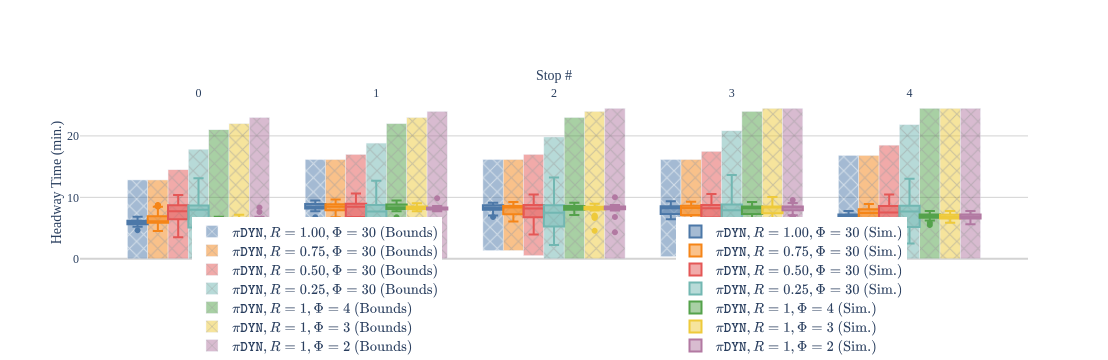

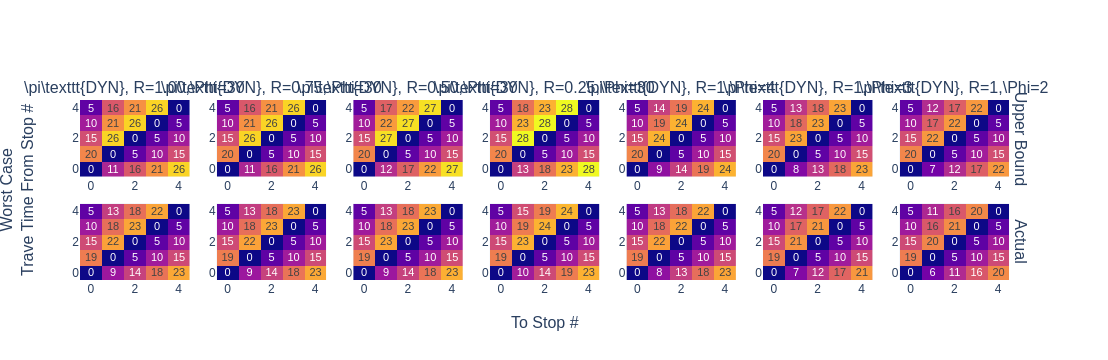

In [12]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(5)
]

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE0 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE0[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE0[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 30}
#RATIO_ROUTE0[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE0[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE1 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE1[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE1[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': 30}
#RATIO_ROUTE1[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE1[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE2 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE2[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE2[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.5, 'max_holding': 30}
#RATIO_ROUTE2[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE2[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.5, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE3 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE3[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE3[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.25, 'max_holding': 30}
#RATIO_ROUTE3[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE3[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.25, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE4 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE4[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE4[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 4}
#RATIO_ROUTE4[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE4[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 3}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE5 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE5[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE5[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 3}
#RATIO_ROUTE5[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE5[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 2}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE6 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE6[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE6[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 2}
#RATIO_ROUTE6[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE6[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 1}

routes = {
    r'\pi\texttt{DYN}, R=1.00,\Phi=30': RATIO_ROUTE0,
    r'\pi\texttt{DYN}, R=0.75,\Phi=30': RATIO_ROUTE1,
    r'\pi\texttt{DYN}, R=0.50,\Phi=30': RATIO_ROUTE2,
    r'\pi\texttt{DYN}, R=0.25,\Phi=30': RATIO_ROUTE3,
    r'\pi\texttt{DYN}, R=1,\Phi=4': RATIO_ROUTE4,
    r'\pi\texttt{DYN}, R=1,\Phi=3': RATIO_ROUTE5,
    r'\pi\texttt{DYN}, R=1,\Phi=2': RATIO_ROUTE6,
}

run_experiment(
    exp_id='midpoint_holding',
    routes=routes,
    start_times=[0, 10, 20],
    t_max=60 * 24 * 7,
)

## Number of Buses

Working on $\pi\texttt{SCH}\;@s^{(0)}, M=2$...
Working on $\pi\texttt{DYN}\;@s^{(0)}, M=2$...
Working on $\pi\texttt{SCH}\;@s^{(0)}, M=3$...
Working on $\pi\texttt{DYN}\;@s^{(0)}, M=3$...
Working on $\pi\texttt{SCH}\;@s^{(0)}, M=4$...
Working on $\pi\texttt{DYN}\;@s^{(0)}, M=4$...


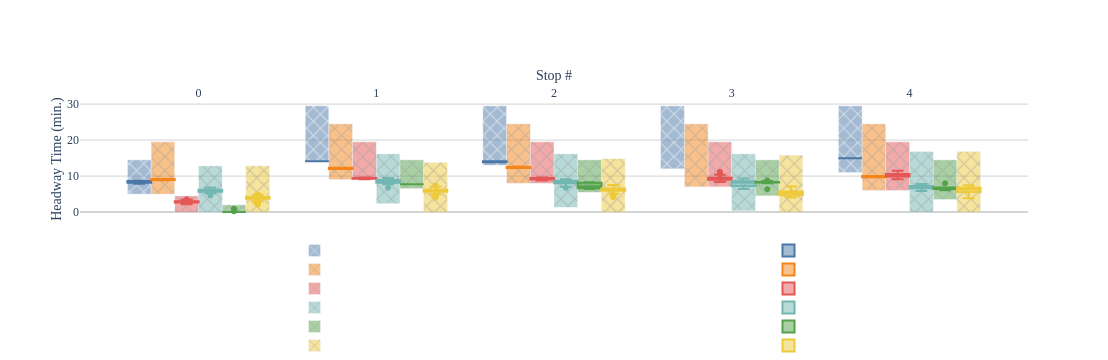

In [183]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}

# Scheduled terminal departure
SCHED_ROUTE2 = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE2[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE2[0]['policy_args'] = {'time_delta': 15, 'offset': 0}

# Scheduled terminal departure
SCHED_ROUTE4 = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE4[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE4[0]['policy_args'] = {'time_delta': 7.5, 'offset': 0}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}


routes = {
    r'$\pi\texttt{SCH}\;@s^{(0)}, M=2$': (SCHED_ROUTE2, [0, 15]),
    r'$\pi\texttt{DYN}\;@s^{(0)}, M=2$': (RATIO_ROUTE, [0, 15]),
    r'$\pi\texttt{SCH}\;@s^{(0)}, M=3$': (SCHED_ROUTE, [0, 10, 20]),
    r'$\pi\texttt{DYN}\;@s^{(0)}, M=3$': (RATIO_ROUTE, [0, 10, 20]), 
    r'$\pi\texttt{SCH}\;@s^{(0)}, M=4$': (SCHED_ROUTE4, [0, 7.5, 15, 22.5]),
    r'$\pi\texttt{DYN}\;@s^{(0)}, M=4$': (RATIO_ROUTE, [0, 7.5, 15, 22.5]), 
}
t_max=60 * 24 * 7
results = {}
for name, route in routes.items():
    print(f'Working on {name}...')
    wc_headway, bc_headway = wcht(route_factory(route[0]), route[1], t_max)
    wc_travel = []
    for i in range(len(route[0])):
        wc_travel.append([])
        for j in range(len(route[0])):
            wc_travel[i].append(wctt(route_factory(route[0]), route[1], wc_headway, i, j))
    prob_results = simulate(route_factory(route[0]), route[1], t_max, seed=0)
    results[name] = {
        'worst_case': {'headway': wc_headway, 'travel': wc_travel},
        'best_case': {'headway': bc_headway},
        'simulation': prob_results,
        'route': route[0]
    }

plot_headway(results)